# The Second Derivative

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture on the **second derivative**
(Week 3 — Optimization in Neural Networks and Newton's Method).

This notebook explains:

- the **second derivative** $f''(x)$ — the derivative of the derivative — and its notation
- the real-world picture: distance → **velocity** → **acceleration**
- the car-trip example (distance, velocity, acceleration side by side)
- **curvature**: concave up / convex ($f'' > 0$) vs. concave down ($f'' < 0$)
- the **second-derivative test** for classifying minima and maxima
- SymPy computations and visualizations

This notebook follows the repository `GUIDELINES.md` template and continues directly from
*Newton's Method* (where the derivative-of-the-derivative first appeared).

## 1. What is the second derivative?

Newton's optimization step used the *derivative of the derivative* — that is the **second
derivative**. Notations:

$$
\text{Leibniz: } \frac{d^2 f}{dx^2} = \frac{d}{dx}\!\left(\frac{d}{dx} f\right),
\qquad
\text{Lagrange: } f''(x).
$$

It carries a lot of information about a function's shape.

## 2. Real-world: velocity and acceleration

If $x(t)$ is the **distance** a car has travelled, the first derivative is its **velocity**:

$$
v = \frac{dx}{dt}.
$$

The rate of change of velocity is the **acceleration** — the second derivative of distance:

$$
a = \frac{dv}{dt} = \frac{d^2 x}{dt^2}.
$$

- $a > 0$: velocity is **increasing**,
- $a < 0$: velocity is **decreasing**,
- $a = 0$: **constant** velocity.

## 3. The car trip: distance → velocity → acceleration

A trip in four phases (time in hours; minutes labelled):

| phase | distance $x(t)$ | velocity $v(t)$ | acceleration $a(t)$ |
|---|---|---|---|
| 0–2 min: speeding up | $750\,t^2$ | $1500\,t$ | $1500$ |
| 2–5 min: cruising | $50\,t - \tfrac{5}{6}$ | $50$ | $0$ |
| 5–7 min: braking & reversing | $-1500\,t^2 + 300\,t - 11.25$ | $300 - 3000\,t$ | $-3000$ |
| 7+ min: returning | $\tfrac{55}{6} - 50\,t$ | $-50$ | $0$ |

Notice the car reaches its **maximum distance** at $t = 6$ min (where $v = 0$), and there the
acceleration is **negative**.

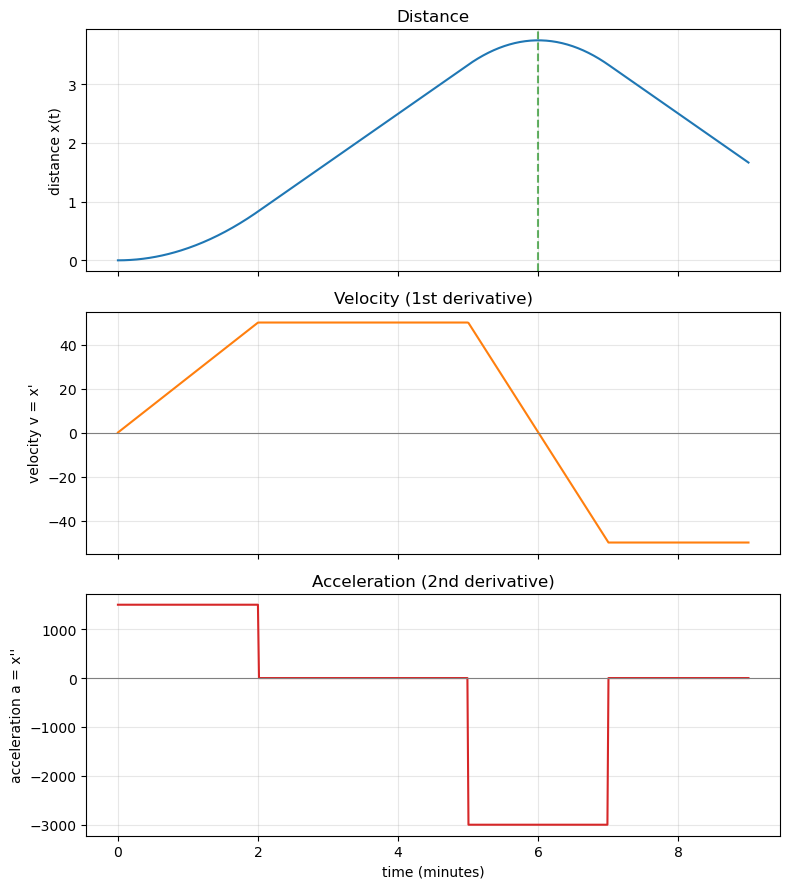

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def car(t):
    # piecewise distance, velocity, acceleration (t in hours)
    t2, t5, t7 = 2/60, 5/60, 7/60
    x = np.where(t < t2, 750*t**2,
        np.where(t < t5, 50*t - 5/6,
        np.where(t < t7, -1500*t**2 + 300*t - 11.25,
                 55/6 - 50*t)))
    v = np.where(t < t2, 1500*t,
        np.where(t < t5, 50.0,
        np.where(t < t7, 300 - 3000*t,
                 -50.0)))
    a = np.where(t < t2, 1500.0,
        np.where(t < t5, 0.0,
        np.where(t < t7, -3000.0,
                 0.0)))
    return x, v, a

t = np.linspace(0, 9/60, 600)
x, v, a = car(t)
tm = t*60   # minutes for the x-axis

fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
axes[0].plot(tm, x, color="tab:blue");  axes[0].set_ylabel("distance x(t)")
axes[0].axvline(6, color="green", ls="--", alpha=0.6); axes[0].set_title("Distance")
axes[1].plot(tm, v, color="tab:orange"); axes[1].set_ylabel("velocity v = x'")
axes[1].axhline(0, color="gray", lw=0.8); axes[1].set_title("Velocity (1st derivative)")
axes[2].plot(tm, a, color="tab:red");    axes[2].set_ylabel("acceleration a = x''")
axes[2].axhline(0, color="gray", lw=0.8); axes[2].set_title("Acceleration (2nd derivative)")
axes[2].set_xlabel("time (minutes)")
for ax in axes: ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. The second derivative is curvature

> *"The second derivative gives a measure of the amount by which a curve deviates from being
> a straight line. This is called the curvature."*

- $f'' > 0$: **concave up** (also *convex*) — a "happy face"; the function increases at an
  increasing rate.
- $f'' < 0$: **concave down** — a "sad face".
- $f'' = 0$: no curvature there (inconclusive).

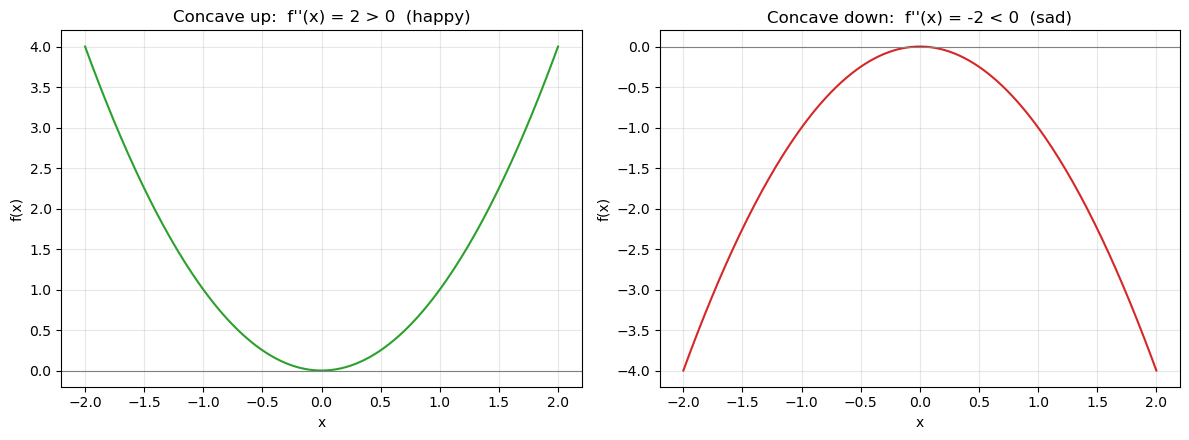

In [2]:
xs = np.linspace(-2, 2, 200)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(xs, xs**2, color="tab:green")
axes[0].set_title("Concave up:  f''(x) = 2 > 0  (happy)")
axes[1].plot(xs, -xs**2, color="tab:red")
axes[1].set_title("Concave down:  f''(x) = -2 < 0  (sad)")
for ax in axes:
    ax.axhline(0, color="gray", lw=0.8); ax.grid(True, alpha=0.3)
    ax.set_xlabel("x"); ax.set_ylabel("f(x)")
plt.tight_layout()
plt.show()

## 5. The second-derivative test for optimization

Points where $f'(x) = 0$ are **candidates** for a minimum or maximum. The **second
derivative** tells them apart:

| at a point with $f'(x)=0$ | $f''(x) > 0$ | $f''(x) < 0$ | $f''(x) = 0$ |
|---|---|---|---|
| conclusion | concave up → **local minimum** | concave down → **local maximum** | inconclusive |

In short: the **first** derivative finds the candidates; the **second** derivative
classifies them.

In [3]:
import sympy as sp

x = sp.symbols('x')
f = x**3 - 3*x        # f'(x)=3x²-3 -> critical points x=±1

fp  = sp.diff(f, x)
fpp = sp.diff(f, x, 2)
print("f(x)   =", f)
print("f'(x)  =", fp)
print("f''(x) =", fpp)

crit = sp.solve(fp, x)
for c in crit:
    second = fpp.subs(x, c)
    kind = "local minimum" if second > 0 else "local maximum" if second < 0 else "inconclusive"
    print(f"  x = {c}: f'' = {second}  ->  {kind}")

f(x)   = x**3 - 3*x
f'(x)  = 3*x**2 - 3
f''(x) = 6*x
  x = -1: f'' = -6  ->  local maximum
  x = 1: f'' = 6  ->  local minimum


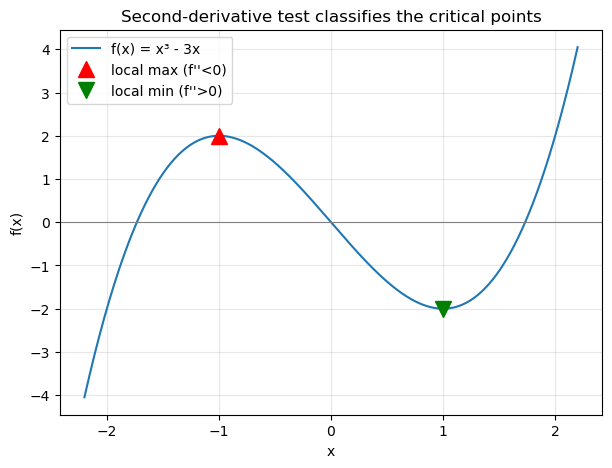

In [4]:
xs = np.linspace(-2.2, 2.2, 400)
fnum = xs**3 - 3*xs
plt.figure(figsize=(7, 5))
plt.plot(xs, fnum, label="f(x) = x³ - 3x")
plt.plot(-1, (-1)**3 - 3*(-1), "r^", markersize=12, label="local max (f''<0)")
plt.plot(1, 1**3 - 3*1, "gv", markersize=12, label="local min (f''>0)")
plt.axhline(0, color="gray", lw=0.8)
plt.title("Second-derivative test classifies the critical points")
plt.xlabel("x"); plt.ylabel("f(x)")
plt.grid(True, alpha=0.3); plt.legend()
plt.show()

## 6. Exercises

### Basic
1. Write the two notations for the second derivative.
2. In the car analogy, what physical quantity is the second derivative of distance?

### Intermediate
3. Compute $f''(x)$ for $f(x) = x^3 - 3x$ and evaluate it at $x = -1$ and $x = 1$.
4. State the second-derivative test in your own words.

### Advanced
5. Classify the critical points of $f(x) = x^4 - 2x^2$ using the second-derivative test.
6. At $x = 0$ for $f(x) = x^4$, the test is inconclusive ($f''(0)=0$). Determine the true
   nature of that point another way.

## 7. Solutions / Checks

In [5]:
x = sp.symbols('x')

# 3.
f = x**3 - 3*x
print("3. f'' =", sp.diff(f, x, 2), "; at -1:", sp.diff(f,x,2).subs(x,-1), ", at 1:", sp.diff(f,x,2).subs(x,1))

# 5.
g = x**4 - 2*x**2
gp, gpp = sp.diff(g, x), sp.diff(g, x, 2)
for c in sp.solve(gp, x):
    s = gpp.subs(x, c)
    kind = "min" if s > 0 else "max" if s < 0 else "inconclusive"
    print(f"5. x={c}: f''={s} -> {kind}")

# 6. x^4 at 0
print("6. f(x)=x⁴: f''(0)=0 (inconclusive), but f(x)≥0 with equality only at 0, so x=0 is a minimum.")

print("1. d²f/dx² (Leibniz) and f''(x) (Lagrange).")
print("2. acceleration.")
print("4. If f'(x)=0 and f''(x)>0 it's a local min; if f''(x)<0 a local max; if 0, inconclusive.")

3. f'' = 6*x ; at -1: -6 , at 1: 6
5. x=-1: f''=8 -> min
5. x=0: f''=-4 -> max
5. x=1: f''=8 -> min
6. f(x)=x⁴: f''(0)=0 (inconclusive), but f(x)≥0 with equality only at 0, so x=0 is a minimum.
1. d²f/dx² (Leibniz) and f''(x) (Lagrange).
2. acceleration.
4. If f'(x)=0 and f''(x)>0 it's a local min; if f''(x)<0 a local max; if 0, inconclusive.


## 8. Conclusion

- The **second derivative** $f''(x) = \dfrac{d^2 f}{dx^2}$ is the derivative of the
  derivative — the **acceleration** to the first derivative's velocity.
- It measures **curvature**: $f'' > 0$ is concave up (convex), $f'' < 0$ is concave down,
  $f'' = 0$ is inconclusive.
- The **second-derivative test** classifies critical points: at $f'(x)=0$, a positive
  $f''$ means a minimum, a negative $f''$ means a maximum.
- This is exactly the ingredient Newton's method uses, and in **many variables** the second
  derivative becomes the **Hessian** matrix — the next topic.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/index.mp4`), the Coursera *Calculus for Machine Learning and Data Science*
(Week 3) lecture on **the second derivative**. Key spoken points, lightly cleaned:

> The derivative of a derivative is the second derivative, written $d^2f/dx^2$ or $f''(x)$.
> Just as the first derivative of distance is velocity, the second derivative is
> acceleration ($a = dv/dt = d^2x/dt^2$): positive means velocity increasing, negative
> decreasing, zero constant. In a car trip, distance $750t^2$ gives velocity $1500t$ and
> acceleration $1500$; cruising ($50t - 5/6$) gives velocity $50$, acceleration $0$; braking
> ($-1500t^2 + 300t - 11.25$) gives velocity $300 - 3000t$, acceleration $-3000$; returning
> gives velocity $-50$, acceleration $0$. The car's maximum distance is where velocity is
> zero and acceleration is negative. The second derivative measures curvature: positive →
> concave up / convex (happy face), negative → concave down (sad face), zero →
> inconclusive. For optimization, among points with $f'=0$, a positive second derivative
> means a local minimum and a negative one a local maximum.